# AQI Prediction — Exploratory Data Analysis

This notebook explores the historical weather + air pollution dataset built by the
backfill pipeline (`backfill_data.py`), before moving on to model training.

**Goals:**
- Understand the shape, quality, and ranges of the data
- Spot trends over time (daily/weekly/seasonal patterns)
- Check correlations between weather variables, pollutants, and AQI
- Identify outliers or data issues to handle before training


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
pd.set_option("display.max_columns", None)


## 1. Load Data

Adjust `DATA_PATH` below to point at your generated CSV
(e.g. the output of `backfill()` — default was `src/data/aqi_history.csv`).

In [26]:
DATA_PATH = "D:/AQI_Project/src/data/aqi_history.csv" 

df = pd.read_csv(DATA_PATH, parse_dates=["datetime"])
df = df.sort_values("datetime").reset_index(drop=True)

print(f"Rows: {len(df)}")
print(f"Date range: {df['datetime'].min()}  ->  {df['datetime'].max()}")
df.head()


Rows: 2208
Date range: 2026-04-17 00:00:00  ->  2026-07-17 23:00:00


,temperature,humidity,pressure,datetime,pm10,pm2_5,co,no,no2,o3,so2,nh3,aqi,hour,day,month,day_of_week,week_of_year,aqi_change_rate
0,19.9,67,1011.6,2026-04-17 00:00:00,51.7,43.1,285.0,0.1,36.6,37.0,6.1,NaN,85,0,17,4,4,16,NaN
1,19.1,73,1012.3,2026-04-17 01:00:00,40.3,32.4,295.0,0.0,23.3,62.0,5.3,NaN,85,1,17,4,4,16,0.0
2,18.5,79,1012.4,2026-04-17 02:00:00,36.7,20.5,307.0,0.0,13.3,79.0,4.7,NaN,84,2,17,4,4,16,-1.0
3,17.3,86,1012.3,2026-04-17 03:00:00,33.8,17.9,303.0,0.0,10.0,80.0,4.2,NaN,83,3,17,4,4,16,-1.0
4,16.9,87,1012.0,2026-04-17 04:00:00,33.4,18.3,301.0,0.0,10.0,72.0,3.8,NaN,81,4,17,4,4,16,-2.0


## 2. Data Overview

In [27]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2208 entries, 0 to 2207
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   temperature      2208 non-null   float64       
 1   humidity         2208 non-null   int64         
 2   pressure         2208 non-null   float64       
 3   datetime         2208 non-null   datetime64[ns]
 4   pm10             2208 non-null   float64       
 5   pm2_5            2208 non-null   float64       
 6   co               2208 non-null   float64       
 7   no               2208 non-null   float64       
 8   no2              2208 non-null   float64       
 9   o3               2208 non-null   float64       
 10  so2              2208 non-null   float64       
 11  nh3              0 non-null      float64       
 12  aqi              2208 non-null   int64         
 13  hour             2208 non-null   int64         
 14  day              2208 non-null   int64  

In [32]:
df.describe().T


,count,mean,min,25%,50%,75%,max,std
temperature,2208.0,29.326585,16.9,25.9,29.4,32.9,41.0,4.746444
humidity,2208.0,51.692935,14.0,40.0,51.0,63.0,97.0,16.053516
pressure,2208.0,1002.880254,992.9,999.9,1003.1,1005.4,1016.7,4.233322
datetime,2208,2026-06-01 23:30:00,2026-04-17 00:00:00,2026-05-09 23:45:00,2026-06-01 23:30:00,2026-06-24 23:15:00,2026-07-17 23:00:00,NaN
pm10,2208.0,56.016214,3.1,37.0,50.9,68.9,247.7,29.082205
pm2_5,2208.0,35.901087,2.5,24.4,35.5,45.8,91.7,15.459714
co,2208.0,406.751359,125.0,293.0,385.0,502.0,1039.0,144.187602
no,2208.0,0.580571,0.0,0.0,0.1,0.4,9.9,1.109488
no2,2208.0,20.112047,0.0,3.3,16.9,33.5,72.4,17.10712
o3,2208.0,99.957428,0.0,49.0,98.0,152.0,237.0,57.559756


## 3. Missing Values & Duplicates

Gaps here usually mean a failed API call during backfill/live collection — worth
knowing about before training, since some models can't handle NaNs.

In [33]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Missing values per column:")
print(missing if len(missing) else "None")

dup_count = df.duplicated(subset="datetime").sum()
print(f"\nDuplicate timestamps: {dup_count}")

# Check for gaps in the hourly time series
full_range = pd.date_range(df["datetime"].min(), df["datetime"].max(), freq="h")
missing_hours = full_range.difference(df["datetime"])
print(f"Missing hourly timestamps: {len(missing_hours)} out of {len(full_range)} expected")


Missing values per column:
nh3                2208
aqi_change_rate       1
dtype: int64

Duplicate timestamps: 0
Missing hourly timestamps: 0 out of 2208 expected


## 4. AQI Over Time

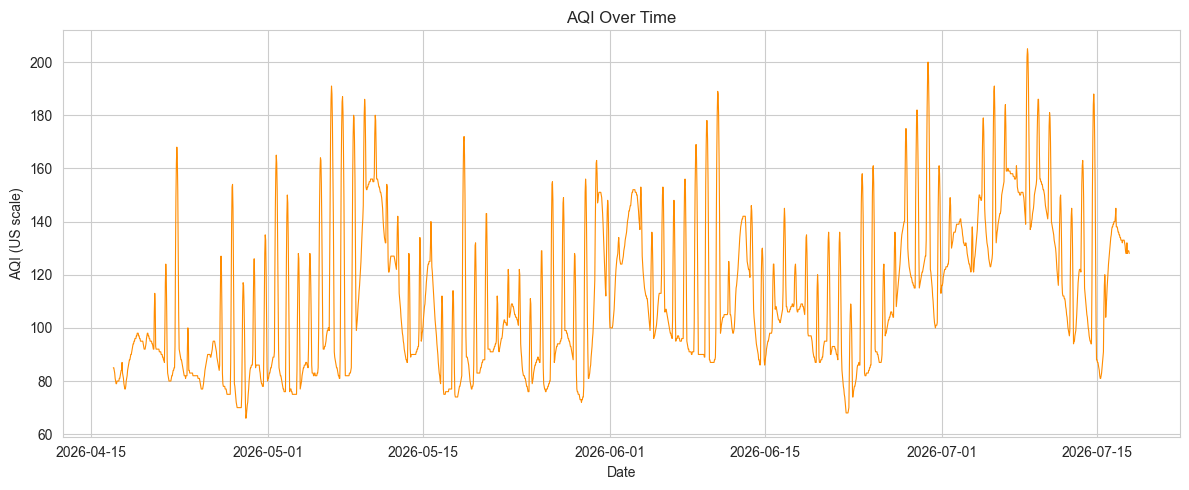

In [30]:
fig, ax = plt.subplots()
ax.plot(df["datetime"], df["aqi"], linewidth=0.8, color="darkorange")
ax.set_title("AQI Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("AQI (US scale)")
plt.tight_layout()
plt.show()


## 5. Weather Variables Over Time

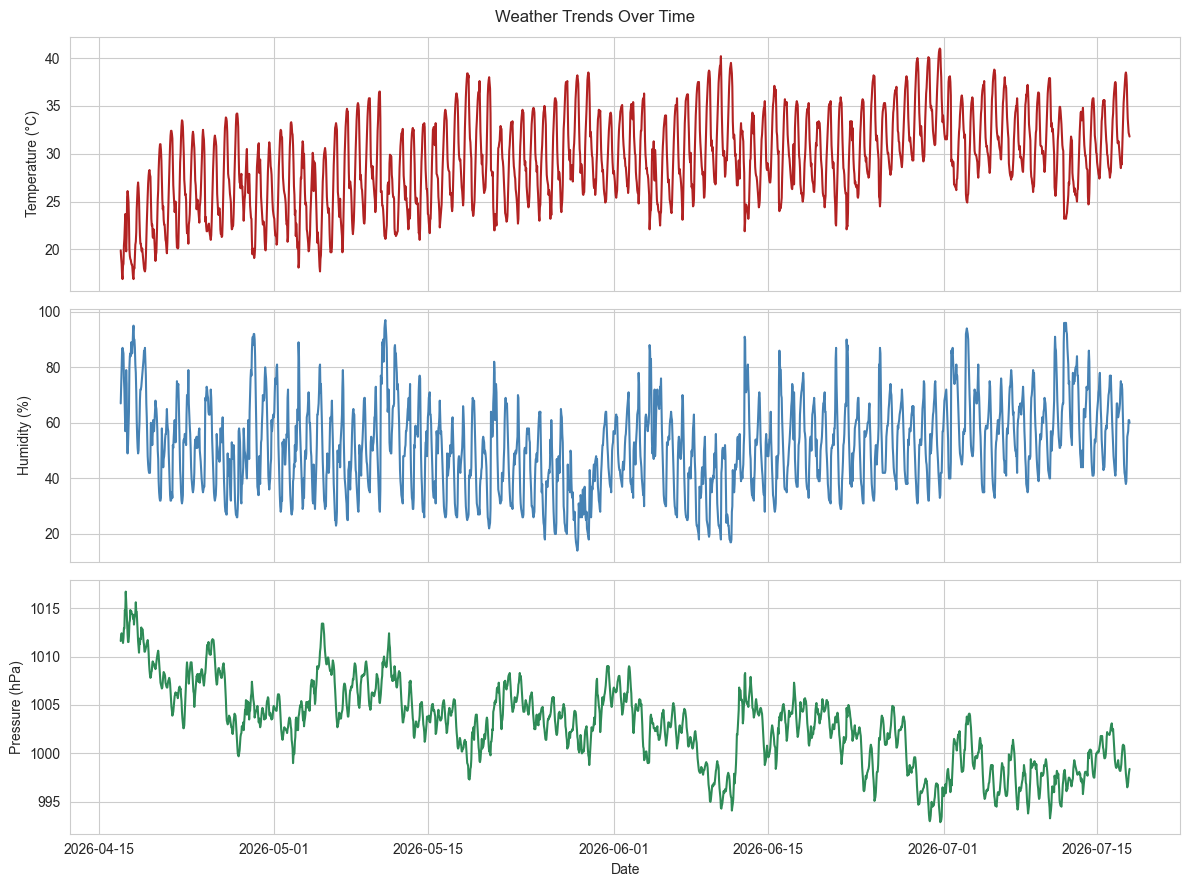

In [34]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

axes[0].plot(df["datetime"], df["temperature"], color="firebrick")
axes[0].set_ylabel("Temperature (°C)")

axes[1].plot(df["datetime"], df["humidity"], color="steelblue")
axes[1].set_ylabel("Humidity (%)")

axes[2].plot(df["datetime"], df["pressure"], color="seagreen")
axes[2].set_ylabel("Pressure (hPa)")
axes[2].set_xlabel("Date")

plt.suptitle("Weather Trends Over Time")
plt.tight_layout()
plt.show()


## 6. Distributions

How AQI and the individual pollutants are spread out — useful for spotting
skew, and deciding whether to transform any features before modeling.

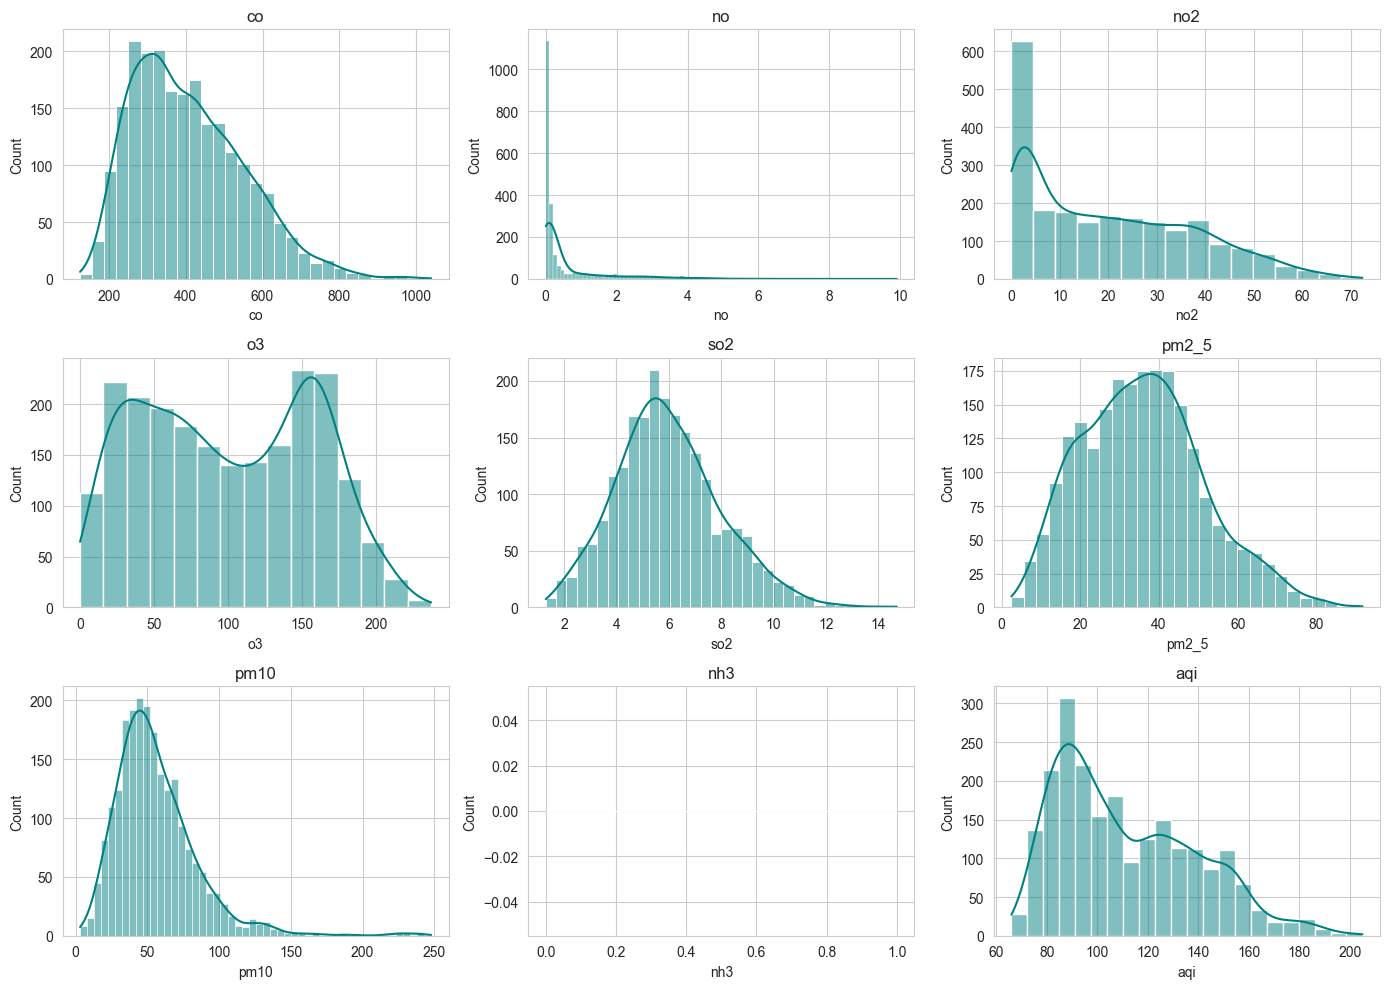

In [35]:
pollutant_cols = ["co", "no", "no2", "o3", "so2", "pm2_5", "pm10", "nh3", "aqi"]

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(pollutant_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color="teal")
    axes[i].set_title(col)

plt.tight_layout()
plt.show()


## 7. Outlier Check (Boxplots)

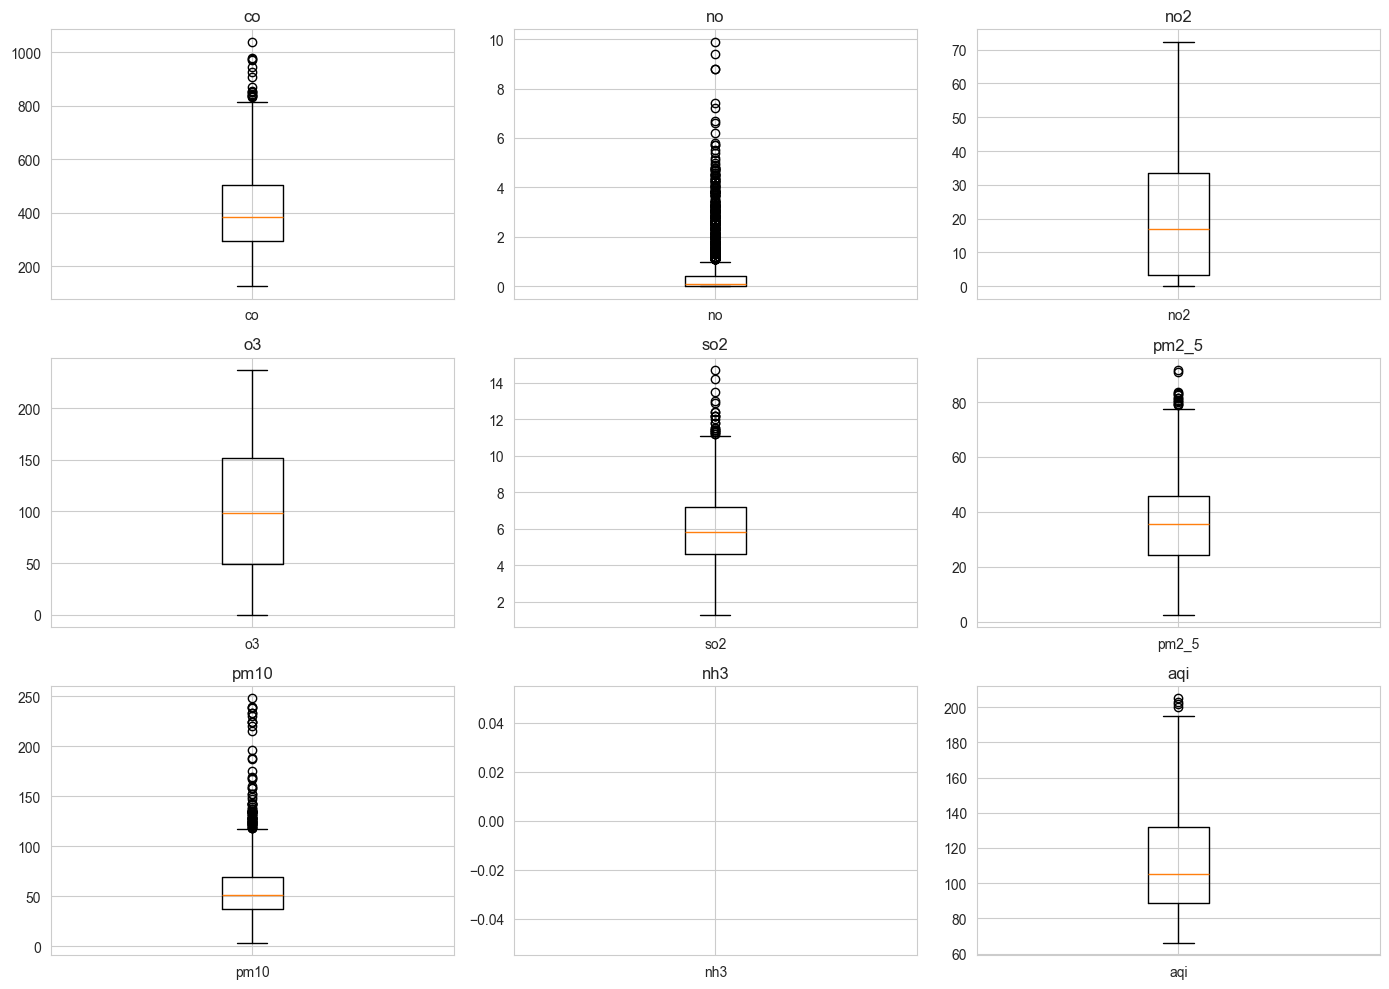

In [36]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(pollutant_cols):
    data = df[col].dropna().values
    axes[i].boxplot(data)
    axes[i].set_title(col)
    axes[i].set_xticklabels([col])

plt.tight_layout()
plt.show()

In [37]:
def find_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] < lower) | (df[col] > upper)]

for col in pollutant_cols:
    outliers = find_outliers_iqr(df, col)
    print(f"{col}: {len(outliers)} outliers")

co: 16 outliers
no: 383 outliers
no2: 0 outliers
o3: 0 outliers
so2: 23 outliers
pm2_5: 14 outliers
pm10: 78 outliers
nh3: 0 outliers
aqi: 4 outliers


## 8. Correlation Analysis

Which variables move together with AQI — helps decide which features matter
most for the model, and flags multicollinearity (e.g. pm2_5 vs pm10).

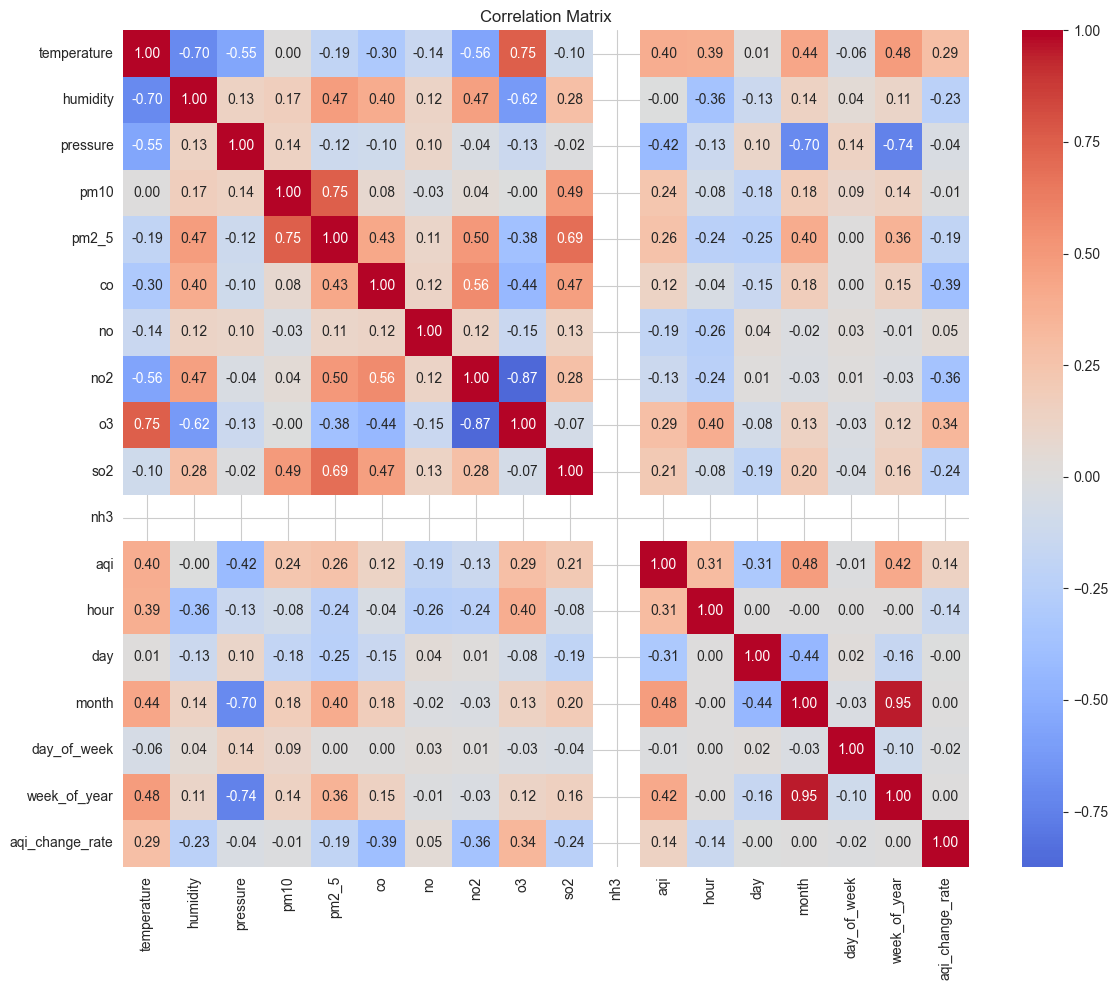

In [38]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Matrix")
plt.tight_layout()
plt.show()


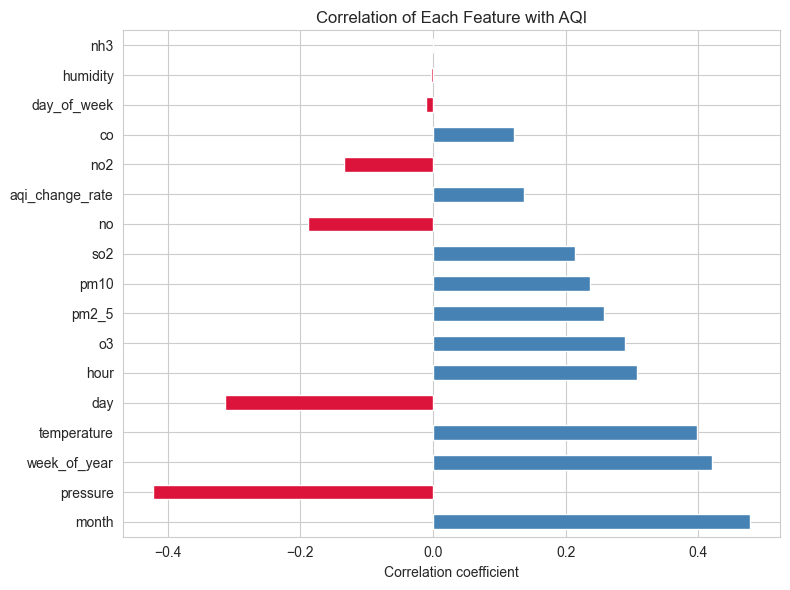

month              0.478144
pressure          -0.421661
week_of_year       0.421358
temperature        0.398080
day               -0.313215
hour               0.308126
o3                 0.288818
pm2_5              0.257373
pm10               0.236373
so2                0.213982
no                -0.188523
aqi_change_rate    0.137879
no2               -0.134121
co                 0.122739
day_of_week       -0.009807
humidity          -0.003293
nh3                     NaN
Name: aqi, dtype: float64

In [39]:
aqi_corr = corr["aqi"].drop("aqi").sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
aqi_corr.plot(kind="barh", color=["crimson" if v < 0 else "steelblue" for v in aqi_corr], ax=ax)
ax.set_title("Correlation of Each Feature with AQI")
ax.set_xlabel("Correlation coefficient")
plt.tight_layout()
plt.show()

aqi_corr


## 9. Temporal Patterns

Does AQI follow a daily rhythm (e.g. worse during rush hour) or a weekly one
(e.g. weekdays vs weekends)?

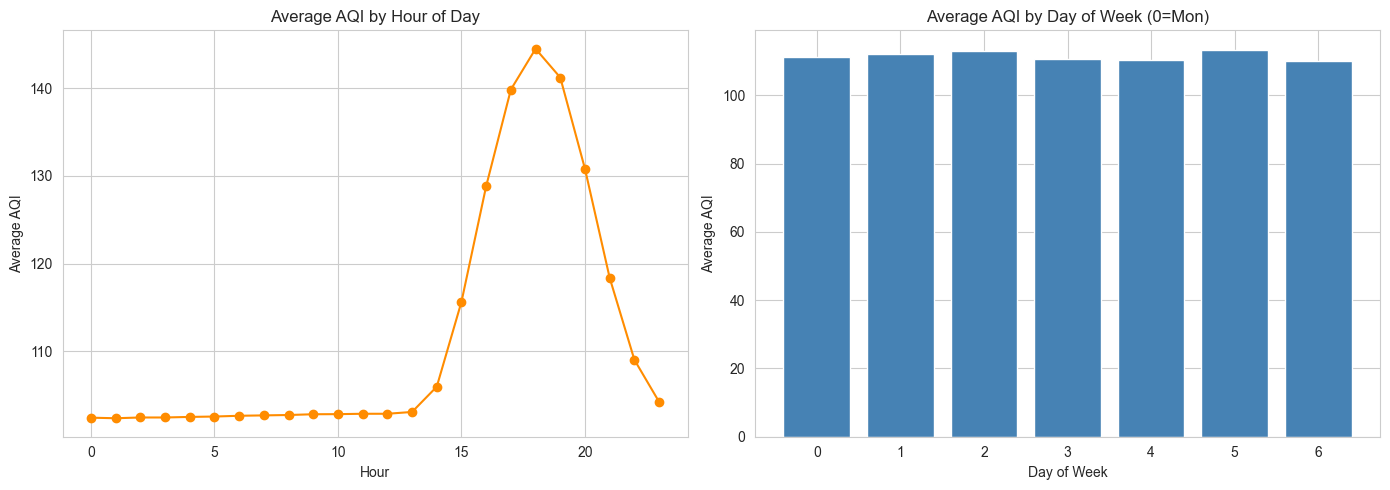

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hourly_avg = df.groupby("hour")["aqi"].mean()
axes[0].plot(hourly_avg.index, hourly_avg.values, marker="o", color="darkorange")
axes[0].set_title("Average AQI by Hour of Day")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Average AQI")

dow_avg = df.groupby("day_of_week")["aqi"].mean()
axes[1].bar(dow_avg.index, dow_avg.values, color="steelblue")
axes[1].set_title("Average AQI by Day of Week (0=Mon)")
axes[1].set_xlabel("Day of Week")
axes[1].set_ylabel("Average AQI")

plt.tight_layout()
plt.show()


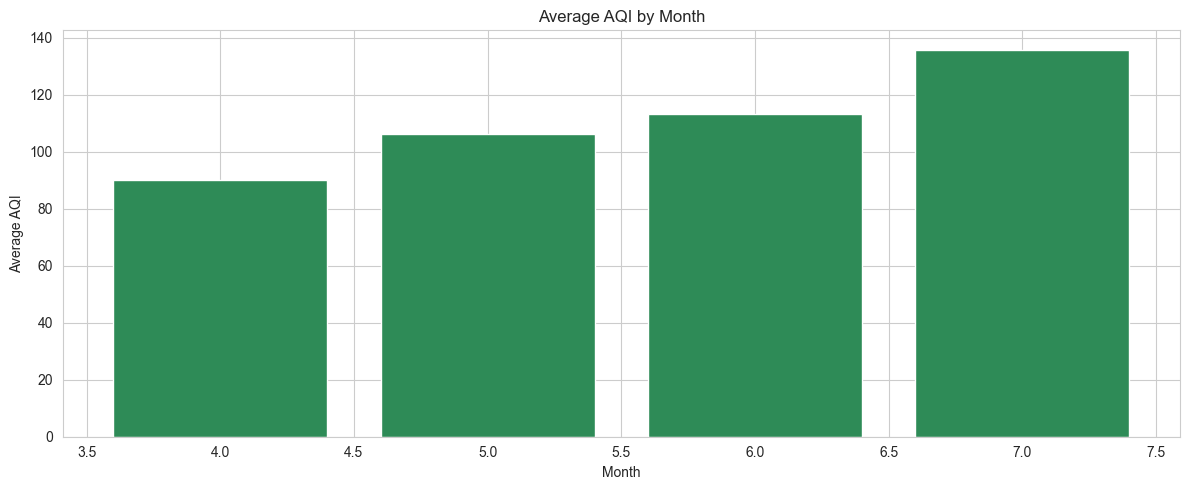

In [41]:
if df["month"].nunique() > 1:
    monthly_avg = df.groupby("month")["aqi"].mean()
    fig, ax = plt.subplots()
    ax.bar(monthly_avg.index, monthly_avg.values, color="seagreen")
    ax.set_title("Average AQI by Month")
    ax.set_xlabel("Month")
    ax.set_ylabel("Average AQI")
    plt.tight_layout()
    plt.show()
else:
    print("Only one month of data present — monthly seasonality can't be assessed yet.")
    print("Consider backfilling a longer date range to capture seasonal patterns.")


## 10. Weather vs. AQI Relationships

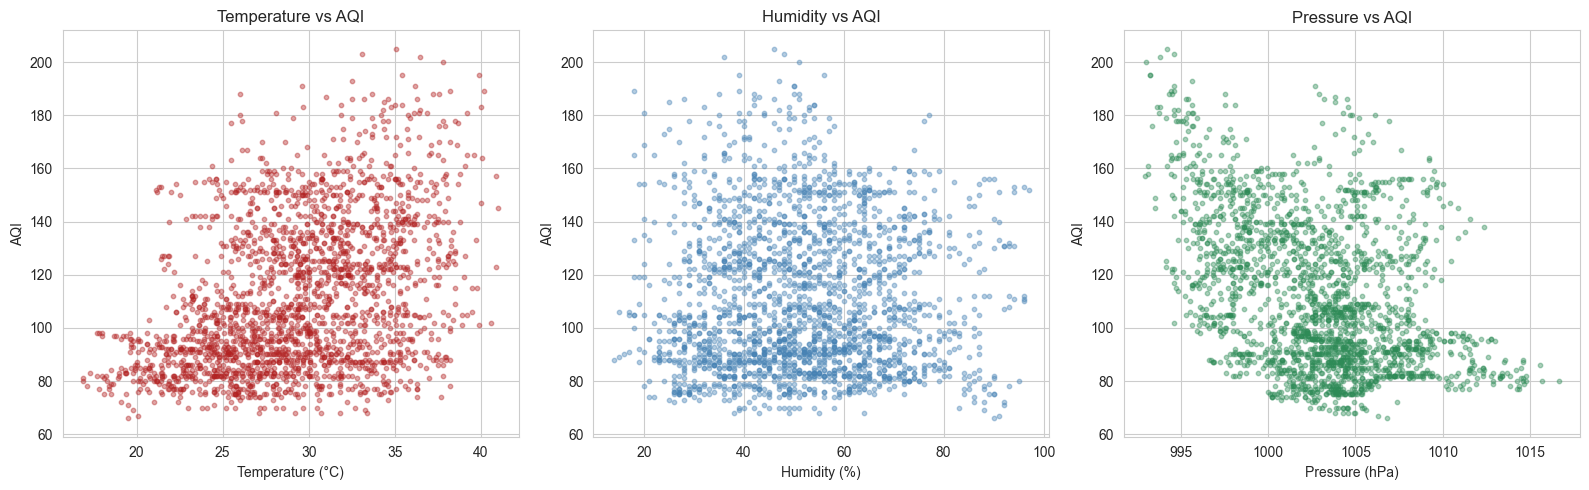

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].scatter(df["temperature"], df["aqi"], alpha=0.4, s=10, color="firebrick")
axes[0].set_xlabel("Temperature (°C)")
axes[0].set_ylabel("AQI")
axes[0].set_title("Temperature vs AQI")

axes[1].scatter(df["humidity"], df["aqi"], alpha=0.4, s=10, color="steelblue")
axes[1].set_xlabel("Humidity (%)")
axes[1].set_ylabel("AQI")
axes[1].set_title("Humidity vs AQI")

axes[2].scatter(df["pressure"], df["aqi"], alpha=0.4, s=10, color="seagreen")
axes[2].set_xlabel("Pressure (hPa)")
axes[2].set_ylabel("AQI")
axes[2].set_title("Pressure vs AQI")

plt.tight_layout()
plt.show()


## 11. AQI Change Rate

Looking at how fast AQI moves hour-to-hour — useful to know if the target is
noisy/volatile (harder to predict) or smooth (easier to predict).

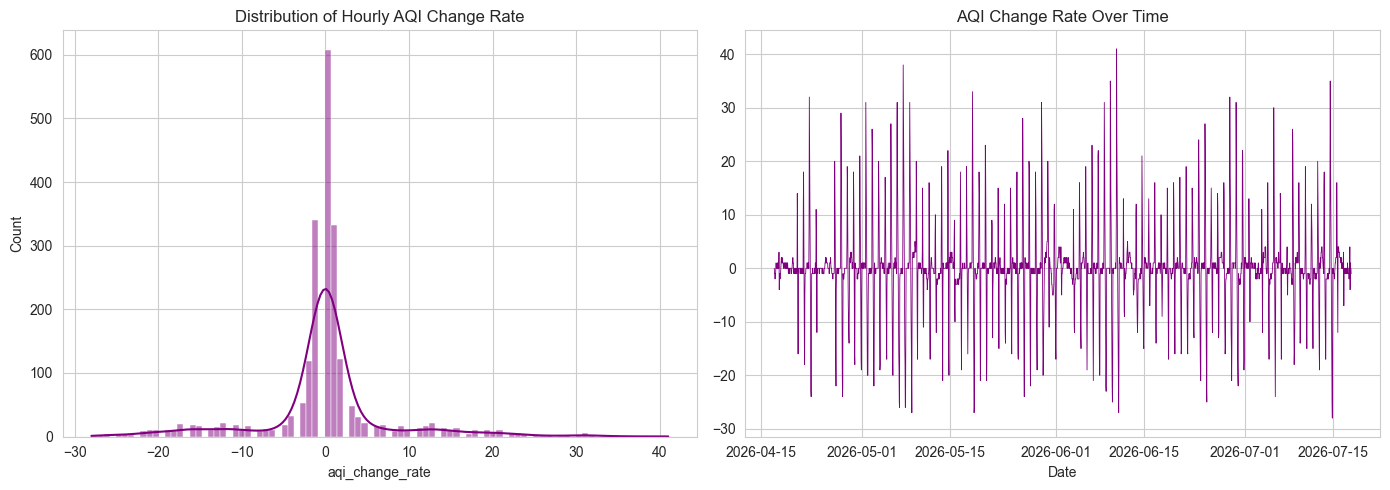

count    2207.000000
mean        0.019483
std         7.681151
min       -28.000000
25%        -1.000000
50%         0.000000
75%         1.000000
max        41.000000
Name: aqi_change_rate, dtype: float64


In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["aqi_change_rate"].dropna(), kde=True, ax=axes[0], color="purple")
axes[0].set_title("Distribution of Hourly AQI Change Rate")

axes[1].plot(df["datetime"], df["aqi_change_rate"], linewidth=0.6, color="purple")
axes[1].set_title("AQI Change Rate Over Time")
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.show()

print(df["aqi_change_rate"].describe())
